In [2]:
# =========================================================
# CELL 1: IMPORT LIBRARIES AND LOAD DATA
# =========================================================

# 1. Import core data handling and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Import statistical function for ANOVA testing
from scipy.stats import f_oneway

# 3. Import preprocessing tools for ML (encoding, pipelines, missing values)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# 4. Import machine learning model and feature importance tool
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

# 5. Import Excel handling and formatting tools
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Border, Side, Alignment
from openpyxl.worksheet.table import Table, TableStyleInfo
from openpyxl.utils import get_column_letter

# 6. Set display options for better visibility of data
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

# 7. Set default style for plots
sns.set_theme(style="whitegrid")

# 8. Define file path and sheet name
file_path = r"D:\Savidhu_OneDrive\OneDrive - Hirdaramani Group\Projects\Cut to Ship Prediction Model\Final Report\Cut to Ship Report-Modified.xlsx"
sheet_name = "All"

# 9. Load dataset from Excel
df_raw = pd.read_excel(file_path, sheet_name=sheet_name)

# 10. Create a working copy of the dataset
df = df_raw.copy()

# 11. Print basic dataset information
print("Dataset loaded successfully")
print("Shape:", df.shape)

# 12. Display column names
print("\nColumns:")
print(df.columns.tolist())

# 13. Preview first few rows of the dataset
df.head()

Dataset loaded successfully
Shape: (15268, 51)

Columns:
['Year', 'Status', 'Sales order', 'Customers', 'Calling Name', 'Div', 'Season', 'Style number', 'Garment item type', 'Unit', 'Operation', 'Last Shipped', 'Style closed date', 'Month', 'Order Qty', 'Cut Qty', 'Ship Qty', 'Cut/Ship', 'Order/Ship', 'Order/Cut', 'SO Type', 'Type', 'Week', 'Operation 2', 'Set garment', 'Pcs', 'FOB', 'FOB-Impact due to Cut to Ship Difference', 'Cut ship Difference', 'Metric A', 'Metric B', 'Metric C', 'Metric D', 'Metric E', 'Metric F', 'Metric G', 'Metric H', 'Metric I', 'Metric J', 'Metric K', 'Metric L', 'Metric M', 'Metric N', 'Metric O', 'Metric P', 'Metric Q', 'Metric R', 'Metric S', 'Vaildation', 'Reasons', 'Code']


,Year,Status,Sales order,Customers,Calling Name,Div,Season,Style number,Garment item type,Unit,Operation,Last Shipped,Style closed date,Month,Order Qty,Cut Qty,Ship Qty,Cut/Ship,Order/Ship,Order/Cut,SO Type,Type,Week,Operation 2,Set garment,Pcs,FOB,FOB-Impact due to Cut to Ship Difference,Cut ship Difference,Metric A,Metric B,Metric C,Metric D,Metric E,Metric F,Metric G,Metric H,Metric I,Metric J,Metric K,Metric L,Metric M,Metric N,Metric O,Metric P,Metric Q,Metric R,Metric S,Vaildation,Reasons,Code
0,2024,Actual,SO1001,Urban Stitch,Urban Stitch,KID,SP24,SN102,T Shirt,A,Performance Wear,2024-04-03,2024-04-04,Jan,1155.0,1186.5,1153.5,0.972187,0.998701,1.027273,Bulk,Non-Wash,Week 01,Knit Operation,Single,1,12019.470,343.860,33.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.0,0.0,True,NaN,SO1001A
1,2024,Actual,SO1002,Urban Stitch,Urban Stitch,KID,SP24,SN103,T Shirt,A,Performance Wear,2024-04-03,2024-04-04,Jan,6001.5,6016.5,6000.0,0.997258,0.999750,1.002499,Bulk,Non-Wash,Week 01,Knit Operation,Single,1,62520.000,171.930,16.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.5,0.0,0.0,0.0,523.5,0.0,0.0,-508.5,0.0,True,NaN,SO1002A
2,2024,Actual,SO1003,Urban Stitch,Urban Stitch,KID,SP24,SN104,T Shirt,A,Performance Wear,2024-04-03,2024-04-04,Jan,12753.0,12777.0,12750.0,0.997887,0.999765,1.001882,Bulk,Non-Wash,Week 01,Knit Operation,Single,1,140122.500,296.730,27.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,0.0,0.0,0.0,0.0,4.5,0.0,10.5,0.0,True,NaN,SO1003A
3,2024,Actual,SO1004,Urban Stitch,Urban Stitch,INF,SP24,SN105,Polo Shirt,A,Performance Wear,2024-04-03,2024-04-04,Jan,19471.5,19645.5,19501.5,0.992670,1.001541,1.008936,Bulk,Non-Wash,Week 01,Knit Operation,Single,1,439563.810,3245.760,144.0,0.0,0.0,0.0,0.0,0.0,0.0,76.5,0.0,0.0,0.0,1.5,0.0,0.0,0.0,31.5,34.5,0.0,0.0,0.0,True,NaN,SO1004A
4,2024,Actual,SO1005,Urban Stitch,Urban Stitch,KID,SP24,SN106,T Shirt,A,Performance Wear,2024-04-03,2024-04-04,Jan,5551.5,5574.0,5551.5,0.995963,1.000000,1.004053,Bulk,Non-Wash,Week 01,Knit Operation,Single,1,61010.985,247.275,22.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,252.0,0.0,0.0,0.0,-232.5,0.0,True,NaN,SO1005A


In [3]:
# =========================================================
# CELL 2: DEFINE COLUMN GROUPS, CLEAN DATA, AND SAVE
# CLEANED WORKBOOK USING ORIGINAL FORMATTING
# FOR ALL / TRAIN / TEST SHEETS
# =========================================================

# 1. Import file handling, numerical, data processing, and Excel libraries
import os
import shutil
import numpy as np
import pandas as pd
from openpyxl import load_workbook

# =========================================================
# FILE PATHS
# =========================================================

# 2. Define original input file path and cleaned output file path
original_file_path = r"D:\Savidhu_OneDrive\OneDrive - Hirdaramani Group\Projects\Cut to Ship Prediction Model\Final Report\Cut to Ship Report-Modified.xlsx"
cleaned_output_path = r"D:\Savidhu_OneDrive\OneDrive - Hirdaramani Group\Projects\Cut to Ship Prediction Model\Final Report\Cut to Ship Modified Cleaned.xlsx"

# 3. Define sheets to clean
sheets_to_clean = ["All", "Train", "Test"]

# =========================================================
# HELPER FUNCTION
# =========================================================

# 4. Create helper function to clean numeric columns
def clean_numeric_series(s):
    s = s.astype(str).str.strip()
    s = s.replace({"": np.nan, "nan": np.nan, "None": np.nan})
    s = s.str.replace(",", "", regex=False)
    s = s.str.replace("%", "", regex=False)
    return pd.to_numeric(s, errors="coerce")

# =========================================================
# CLEAN EACH SHEET
# =========================================================

# 5. Store cleaned data for each sheet
cleaned_sheet_data = {}

# 6. Loop through each required sheet
for sheet_name in sheets_to_clean:
    print(f"\n{'='*70}")
    print(f"CLEANING SHEET: {sheet_name}")
    print(f"{'='*70}")

    # 7. Load sheet and clean column names
    df = pd.read_excel(original_file_path, sheet_name=sheet_name)
    df.columns = df.columns.astype(str).str.strip()

    # -----------------------------
    # Identifier columns
    # -----------------------------

    # 8. Define identifier columns
    id_cols = ["Code", "Sales order", "Style number"]
    id_cols = [c for c in id_cols if c in df.columns]

    # -----------------------------
    # Target columns
    # -----------------------------

    # 9. Define target columns for prediction
    target_cols = ["Cut Qty", "Ship Qty"]
    target_cols = [c for c in target_cols if c in df.columns]

    # -----------------------------
    # Columns to USE for ML
    # -----------------------------

    # 10. Define columns to use as ML features
    use_cols = [
        "Year",
        "Customers",
        "Calling Name",
        "Div",
        "Season",
        "Garment item type",
        "Unit",
        "Operation",
        "Month",
        "Order Qty",
        "Type",
        "Week",
        "Operation 2",
        "Set garment",
        "Pcs"
    ]
    use_cols = [c for c in use_cols if c in df.columns]

    # -----------------------------
    # Columns to DROP from ML
    # kept in full dataset for dashboard/reporting
    # -----------------------------

    # 11. Define columns excluded from ML but kept in full dataset
    drop_cols_ml = [
        "Status",
        "Last Shipped",
        "Style closed date",
        "Cut/Ship",
        "Order/Ship",
        "Order/Cut",
        "SO Type",
        "FOB",
        "FOB-Impact due to Cut to Ship Difference",
        "Cut ship Difference",
        "Metric A",
        "Metric B",
        "Metric C",
        "Metric D",
        "Metric E",
        "Metric F",
        "Metric G",
        "Metric H",
        "Metric I",
        "Metric J",
        "Metric K",
        "Metric L",
        "Metric M",
        "Metric N",
        "Metric O",
        "Metric P",
        "Metric Q",
        "Metric R",
        "Metric S",
        "Vaildation",
        "Validation",
        "Reasons"
    ]
    drop_cols_ml = [c for c in drop_cols_ml if c in df.columns]

    # -----------------------------
    # Final ML feature columns
    # -----------------------------

    # 12. Create final feature list for ML
    feature_cols = use_cols.copy()

    # =========================================================
    # DATA CLEANING ON FULL DATASET
    # =========================================================

    # 13. Define numeric columns that need cleaning
    numeric_candidates = [
        "Order Qty",
        "Cut Qty",
        "Ship Qty",
        "Cut/Ship",
        "Order/Ship",
        "Order/Cut",
        "Cut ship Difference",
        "Pcs",
        "FOB",
        "FOB-Impact due to Cut to Ship Difference",
        "Metric A",
        "Metric B",
        "Metric C",
        "Metric D",
        "Metric E",
        "Metric F",
        "Metric G",
        "Metric H",
        "Metric I",
        "Metric J",
        "Metric K",
        "Metric L",
        "Metric M",
        "Metric N",
        "Metric O",
        "Metric P",
        "Metric Q",
        "Metric R",
        "Metric S"
    ]
    numeric_candidates = [c for c in numeric_candidates if c in df.columns]

    # 14. Clean all numeric columns
    for col in numeric_candidates:
        df[col] = clean_numeric_series(df[col])

    # 15. Keep Week as categorical and clean blank values
    if "Week" in df.columns:
        df["Week"] = df["Week"].astype(str).str.strip()
        df.loc[df["Week"].isin(["nan", "None", ""]), "Week"] = np.nan

    # 16. Clean common text columns
    text_cols = [
        "Customers", "Calling Name", "Div", "Season", "Garment item type",
        "Unit", "Operation", "Month", "Type", "Operation 2", "Set garment",
        "Status", "Reasons", "Vaildation", "Validation", "SO Type"
    ]
    for col in text_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()
            df.loc[df[col].isin(["nan", "None", ""]), col] = np.nan

    # 17. Convert selected columns to datetime
    date_cols = [c for c in ["Last Shipped", "Style closed date"] if c in df.columns]
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors="coerce")

    # =========================================================
    # CREATE ML DATASET
    # =========================================================

    # 18. Create ML-only dataset using identifiers, features, and targets
    ml_cols = id_cols + feature_cols + target_cols
    ml_cols = [c for c in ml_cols if c in df.columns]
    df_ml = df[ml_cols].copy()

    # 19. Store cleaned full dataset for saving back to workbook
    cleaned_sheet_data[sheet_name] = df.copy()

    # =========================================================
    # SUMMARY
    # =========================================================

    # 20. Print summary for each cleaned sheet
    print("Data cleaning completed")
    print("\nIdentifier columns:", id_cols)
    print("\nTarget columns:", target_cols)
    print("\nFeature columns used for ML:", feature_cols)
    print("\nExcluded from ML (kept in df):", drop_cols_ml)
    print("\nFull dataset shape (df):", df.shape)
    print("ML dataset shape (df_ml):", df_ml.shape)

    # 21. Preview cleaned ML dataset
    display(df_ml.head())

# =========================================================
# SAVE CLEANED DATASET FOR DASHBOARD
# PRESERVE ORIGINAL WORKBOOK LOOK/FORMATTING
# FOR ALL / TRAIN / TEST SHEETS
# =========================================================

# 22. Copy original workbook to create cleaned version
shutil.copy2(original_file_path, cleaned_output_path)

# 23. Open copied workbook
wb = load_workbook(cleaned_output_path)

# 24. Update each required sheet in the copied workbook
for sheet_name in sheets_to_clean:
    if sheet_name not in wb.sheetnames:
        print(f"Sheet not found in workbook: {sheet_name}")
        continue

    # 25. Access worksheet and corresponding cleaned dataframe
    ws = wb[sheet_name]
    df_clean = cleaned_sheet_data[sheet_name]

    # 26. Read original Excel header order
    excel_headers = [ws.cell(row=1, column=i).value for i in range(1, ws.max_column + 1)]

    # 27. Delete old data rows but keep header and sheet formatting
    if ws.max_row > 1:
        ws.delete_rows(2, ws.max_row - 1)

    # 28. Write cleaned data back in original column order
    for row_idx, (_, row) in enumerate(df_clean.iterrows(), start=2):
        for col_idx, col_name in enumerate(excel_headers, start=1):
            value = row[col_name] if col_name in df_clean.columns else None

            # 29. Preserve missing values as blank Excel cells
            if pd.isna(value):
                value = None

            ws.cell(row=row_idx, column=col_idx, value=value)

    print(f"Updated sheet: {sheet_name}")

# 30. Save cleaned workbook
wb.save(cleaned_output_path)

# 31. Print final save location
print("\nCleaned workbook saved to:")
print(cleaned_output_path)


CLEANING SHEET: All
Data cleaning completed

Identifier columns: ['Code', 'Sales order', 'Style number']

Target columns: ['Cut Qty', 'Ship Qty']

Feature columns used for ML: ['Year', 'Customers', 'Calling Name', 'Div', 'Season', 'Garment item type', 'Unit', 'Operation', 'Month', 'Order Qty', 'Type', 'Week', 'Operation 2', 'Set garment', 'Pcs']

Excluded from ML (kept in df): ['Status', 'Last Shipped', 'Style closed date', 'Cut/Ship', 'Order/Ship', 'Order/Cut', 'SO Type', 'FOB', 'FOB-Impact due to Cut to Ship Difference', 'Cut ship Difference', 'Metric A', 'Metric B', 'Metric C', 'Metric D', 'Metric E', 'Metric F', 'Metric G', 'Metric H', 'Metric I', 'Metric J', 'Metric K', 'Metric L', 'Metric M', 'Metric N', 'Metric O', 'Metric P', 'Metric Q', 'Metric R', 'Metric S', 'Vaildation', 'Reasons']

Full dataset shape (df): (15268, 51)
ML dataset shape (df_ml): (15268, 20)


,Code,Sales order,Style number,Year,Customers,Calling Name,Div,Season,Garment item type,Unit,Operation,Month,Order Qty,Type,Week,Operation 2,Set garment,Pcs,Cut Qty,Ship Qty
0,SO1001A,SO1001,SN102,2024,Urban Stitch,Urban Stitch,KID,SP24,T Shirt,A,Performance Wear,Jan,1155.0,Non-Wash,Week 01,Knit Operation,Single,1,1186.5,1153.5
1,SO1002A,SO1002,SN103,2024,Urban Stitch,Urban Stitch,KID,SP24,T Shirt,A,Performance Wear,Jan,6001.5,Non-Wash,Week 01,Knit Operation,Single,1,6016.5,6000.0
2,SO1003A,SO1003,SN104,2024,Urban Stitch,Urban Stitch,KID,SP24,T Shirt,A,Performance Wear,Jan,12753.0,Non-Wash,Week 01,Knit Operation,Single,1,12777.0,12750.0
3,SO1004A,SO1004,SN105,2024,Urban Stitch,Urban Stitch,INF,SP24,Polo Shirt,A,Performance Wear,Jan,19471.5,Non-Wash,Week 01,Knit Operation,Single,1,19645.5,19501.5
4,SO1005A,SO1005,SN106,2024,Urban Stitch,Urban Stitch,KID,SP24,T Shirt,A,Performance Wear,Jan,5551.5,Non-Wash,Week 01,Knit Operation,Single,1,5574.0,5551.5



CLEANING SHEET: Train
Data cleaning completed

Identifier columns: ['Code', 'Sales order', 'Style number']

Target columns: ['Cut Qty', 'Ship Qty']

Feature columns used for ML: ['Year', 'Customers', 'Calling Name', 'Div', 'Season', 'Garment item type', 'Unit', 'Operation', 'Month', 'Order Qty', 'Type', 'Week', 'Operation 2', 'Set garment', 'Pcs']

Excluded from ML (kept in df): ['Status', 'Last Shipped', 'Style closed date', 'Cut/Ship', 'Order/Ship', 'Order/Cut', 'SO Type', 'FOB', 'FOB-Impact due to Cut to Ship Difference', 'Cut ship Difference', 'Metric A', 'Metric B', 'Metric C', 'Metric D', 'Metric E', 'Metric F', 'Metric G', 'Metric H', 'Metric I', 'Metric J', 'Metric K', 'Metric L', 'Metric M', 'Metric N', 'Metric O', 'Metric P', 'Metric Q', 'Metric R', 'Metric S', 'Vaildation', 'Reasons']

Full dataset shape (df): (12482, 51)
ML dataset shape (df_ml): (12482, 20)


,Code,Sales order,Style number,Year,Customers,Calling Name,Div,Season,Garment item type,Unit,Operation,Month,Order Qty,Type,Week,Operation 2,Set garment,Pcs,Cut Qty,Ship Qty
0,SO1001A,SO1001,SN102,2024,Urban Stitch,Urban Stitch,KID,SP24,T Shirt,A,Performance Wear,Jan,1155.0,Non-Wash,Week 01,Knit Operation,Single,1,1186.5,1153.5
1,SO1002A,SO1002,SN103,2024,Urban Stitch,Urban Stitch,KID,SP24,T Shirt,A,Performance Wear,Jan,6001.5,Non-Wash,Week 01,Knit Operation,Single,1,6016.5,6000.0
2,SO1003A,SO1003,SN104,2024,Urban Stitch,Urban Stitch,KID,SP24,T Shirt,A,Performance Wear,Jan,12753.0,Non-Wash,Week 01,Knit Operation,Single,1,12777.0,12750.0
3,SO1004A,SO1004,SN105,2024,Urban Stitch,Urban Stitch,INF,SP24,Polo Shirt,A,Performance Wear,Jan,19471.5,Non-Wash,Week 01,Knit Operation,Single,1,19645.5,19501.5
4,SO1005A,SO1005,SN106,2024,Urban Stitch,Urban Stitch,KID,SP24,T Shirt,A,Performance Wear,Jan,5551.5,Non-Wash,Week 01,Knit Operation,Single,1,5574.0,5551.5



CLEANING SHEET: Test
Data cleaning completed

Identifier columns: ['Code', 'Sales order', 'Style number']

Target columns: ['Cut Qty', 'Ship Qty']

Feature columns used for ML: ['Year', 'Customers', 'Calling Name', 'Div', 'Season', 'Garment item type', 'Unit', 'Operation', 'Month', 'Order Qty', 'Type', 'Week', 'Operation 2', 'Set garment', 'Pcs']

Excluded from ML (kept in df): ['Status', 'Last Shipped', 'Style closed date', 'Cut/Ship', 'Order/Ship', 'Order/Cut', 'SO Type', 'FOB', 'FOB-Impact due to Cut to Ship Difference', 'Cut ship Difference', 'Metric A', 'Metric B', 'Metric C', 'Metric D', 'Metric E', 'Metric F', 'Metric G', 'Metric H', 'Metric I', 'Metric J', 'Metric K', 'Metric L', 'Metric M', 'Metric N', 'Metric O', 'Metric P', 'Metric Q', 'Metric R', 'Metric S', 'Vaildation', 'Reasons']

Full dataset shape (df): (2786, 51)
ML dataset shape (df_ml): (2786, 20)


,Code,Sales order,Style number,Year,Customers,Calling Name,Div,Season,Garment item type,Unit,Operation,Month,Order Qty,Type,Week,Operation 2,Set garment,Pcs,Cut Qty,Ship Qty
0,SO13483A,SO13483,SN12584,2025,Prime Fit Apparel,Prime Fit Apparel,KID,HO26,Dress Shirt,A,Performance Wear,Sep,1998.0,Non Wash,Week 40,Knit Operation,Pack,3,2061.0,2016.0
1,SO13484A,SO13484,SN12585,2025,Clothify Apparel,Clothify Apparel,ACT,G324,Dress Shirt,A,Performance Wear,Sep,2773.5,Non Wash,Week 40,Knit Operation,Single,1,2950.5,2907.0
2,SO13485A,SO13485,SN12585,2025,Clothify Apparel,Clothify Apparel,ACT,G324,Dress Shirt,A,Performance Wear,Sep,3577.5,Non Wash,Week 40,Knit Operation,Single,1,3672.0,3627.0
3,SO13486A,SO13486,SN12585,2025,Clothify Apparel,Clothify Apparel,ACT,G324,Dress Shirt,A,Performance Wear,Sep,2811.0,Non Wash,Week 40,Knit Operation,Single,1,2868.0,2871.0
4,SO13487A,SO13487,SN12588,2025,Clothify Apparel,Clothify Apparel,KID,G324,Dress Shirt,A,Performance Wear,Sep,6184.5,Non Wash,Week 40,Knit Operation,Single,1,6288.0,6183.0


Updated sheet: All
Updated sheet: Train
Updated sheet: Test

Cleaned workbook saved to:
D:\Savidhu_OneDrive\OneDrive - Hirdaramani Group\Projects\Cut to Ship Prediction Model\Final Report\Cut to Ship Modified Cleaned.xlsx


In [7]:
# =========================================================
# CELL 3: DATASET OVERVIEW AND FEATURE SCREENING
# ---------------------------------------------------------
# Uses CLEANED "All" sheet from Cell 2
# =========================================================

# -----------------------------
# USE CLEANED "ALL" DATA
# -----------------------------

# 1. Load cleaned "All" sheet into working dataframe
df = cleaned_sheet_data["All"].copy()

# -----------------------------
# Dataset overview (FULL DATASET)
# -----------------------------

# 2. Create summary table for all columns in the dataset
overview = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Non-Null Count": df.notna().sum().values,
    "Missing Count": df.isna().sum().values,
    "Missing %": (df.isna().mean().values * 100).round(2),
    "Unique Values": [df[c].nunique(dropna=True) for c in df.columns]
})

# 3. Display sorted dataset overview
print("===== DATASET OVERVIEW =====")
display(overview.sort_values(["Missing %", "Unique Values"], ascending=[False, False]))

# -----------------------------
# Feature screening (NO DROPPING)
# -----------------------------

# 4. Create empty list to store feature screening results
screening_rows = []

# 5. Loop through each column and profile it
for col in df.columns:
    dtype = str(df[col].dtype)
    missing_pct = df[col].isna().mean() * 100
    unique_vals = df[col].nunique(dropna=True)

    # 6. Get most common value in the column
    mode_val = df[col].mode(dropna=True)
    mode_val = mode_val.iloc[0] if len(mode_val) > 0 else np.nan

    # 7. Calculate frequency and percentage of the most common value
    top_freq = df[col].value_counts(dropna=True).iloc[0] if unique_vals > 0 else 0
    non_null = df[col].notna().sum()
    top_pct = (top_freq / non_null * 100) if non_null > 0 else np.nan

    # -----------------------------
    # Classification ONLY (no dropping)
    # -----------------------------

    # 8. Classify identifier columns
    if col in id_cols:
        recommendation = "Identifier only"
        reason = "ID field"

    # 9. Classify target columns
    elif col in target_cols:
        recommendation = "Target"
        reason = "Prediction target"

    # 10. Classify approved ML feature columns
    elif col in use_cols:
        recommendation = "Use for ML"
        reason = "Valid pre-order feature"

    # 11. Classify excluded ML columns with reasons
    elif col in drop_cols_ml:
        recommendation = "Do NOT use in ML"

        if col in ["Status", "SO Type"]:
            reason = "One distinct value"
        elif str(col).startswith("Metric "):
            reason = "Operational outcome / difference breakdown field"
        elif col in ["Cut/Ship", "Order/Ship", "Order/Cut", "Cut ship Difference"]:
            reason = "Derived outcome / leakage field"
        elif col in ["Last Shipped", "Style closed date"]:
            reason = "Post-order date field"
        elif col in ["FOB", "FOB-Impact due to Cut to Ship Difference"]:
            reason = "Business impact / reporting field"
        elif col in ["Vaildation", "Validation", "Reasons"]:
            reason = "Validation / explanation field"
        else:
            reason = "Post-order / leakage field"

    # 12. Apply fallback classification for ungrouped columns
    else:
        if unique_vals <= 1:
            recommendation = "Do NOT use in ML"
            reason = "Constant feature"
        elif missing_pct > 50:
            recommendation = "Review"
            reason = "High missingness"
        else:
            recommendation = "Review"
            reason = "Not classified, check manually"

    # 13. Store column screening result
    screening_rows.append({
        "Column": col,
        "Data Type": dtype,
        "Non-Null Count": df[col].notna().sum(),
        "Missing Count": df[col].isna().sum(),
        "Missing %": round(missing_pct, 2),
        "Unique Values": unique_vals,
        "Most Common Value": mode_val,
        "Top Value %": round(top_pct, 2) if pd.notna(top_pct) else np.nan,
        "Recommendation": recommendation,
        "Reason": reason
    })

# 14. Convert screening results into dataframe
feature_screening = pd.DataFrame(screening_rows)

# -----------------------------
# Sorting (clean display)
# -----------------------------

# 15. Define display order for recommendations
recommendation_order = {
    "Use for ML": 1,
    "Target": 2,
    "Identifier only": 3,
    "Do NOT use in ML": 4,
    "Review": 5
}

# 16. Add sorting key to feature screening table
feature_screening["Rec_Order"] = (
    feature_screening["Recommendation"]
    .map(recommendation_order)
    .fillna(99)
)

# 17. Display full feature screening table in sorted order
print("\n===== FEATURE SCREENING (KNOWLEDGE ONLY) =====")
display(
    feature_screening
    .sort_values(["Rec_Order", "Missing %"], ascending=[True, False])
    .drop(columns="Rec_Order")
)

# -----------------------------
# Helpful grouped views
# -----------------------------

# 18. Display only columns used for ML
print("\n===== FEATURES USED FOR ML =====")
display(feature_screening[feature_screening["Recommendation"] == "Use for ML"])

# 19. Display target columns
print("\n===== TARGET COLUMNS =====")
display(feature_screening[feature_screening["Recommendation"] == "Target"])

# 20. Display identifier columns
print("\n===== IDENTIFIER COLUMNS =====")
display(feature_screening[feature_screening["Recommendation"] == "Identifier only"])

# 21. Display columns excluded from ML but kept for dashboard/reporting
print("\n===== NOT USED IN ML (BUT KEPT FOR DASHBOARD) =====")
display(feature_screening[feature_screening["Recommendation"] == "Do NOT use in ML"])

===== DATASET OVERVIEW =====


,Column,Data Type,Non-Null Count,Missing Count,Missing %,Unique Values
49,Reasons,object,12,15256,99.92,1
27,FOB-Impact due to Cut to Ship Difference,float64,15246,22,0.14,12134
11,Last Shipped,datetime64[ns],15267,1,0.01,741
21,Type,object,15267,1,0.01,3
50,Code,object,15268,0,0.00,15268
2,Sales order,object,15268,0,0.00,15184
26,FOB,float64,15268,0,0.00,14333
7,Style number,object,15268,0,0.00,14095
17,Cut/Ship,float64,15268,0,0.00,11967
19,Order/Cut,float64,15268,0,0.00,11102



===== FEATURE SCREENING (KNOWLEDGE ONLY) =====


,Column,Data Type,Non-Null Count,Missing Count,Missing %,Unique Values,Most Common Value,Top Value %,Recommendation,Reason
21,Type,object,15267,1,0.01,3,Non-Wash,46.26,Use for ML,Valid pre-order feature
0,Year,int64,15268,0,0.00,3,2024,47.45,Use for ML,Valid pre-order feature
3,Customers,object,15268,0,0.00,61,Urban Vogue,22.32,Use for ML,Valid pre-order feature
4,Calling Name,object,15268,0,0.00,61,Urban Vogue,22.32,Use for ML,Valid pre-order feature
5,Div,object,15268,0,0.00,50,KID,25.52,Use for ML,Valid pre-order feature
6,Season,object,15268,0,0.00,98,LT24,15.10,Use for ML,Valid pre-order feature
8,Garment item type,object,15268,0,0.00,93,Polo Shirt,12.49,Use for ML,Valid pre-order feature
9,Unit,object,15268,0,0.00,13,E,27.14,Use for ML,Valid pre-order feature
10,Operation,object,15268,0,0.00,3,Performance Wear,50.28,Use for ML,Valid pre-order feature
13,Month,object,15268,0,0.00,12,Feb,13.10,Use for ML,Valid pre-order feature



===== FEATURES USED FOR ML =====


...

,Column,Data Type,Non-Null Count,Missing Count,Missing %,Unique Values,Most Common Value,Top Value %,Recommendation,Reason,Rec_Order
15,Cut Qty,float64,15268,0,0.0,7422,1500.0,0.96,Target,Prediction target,2
16,Ship Qty,float64,15268,0,0.0,6710,1500.0,1.18,Target,Prediction target,2



===== IDENTIFIER COLUMNS =====


,Column,Data Type,Non-Null Count,Missing Count,Missing %,Unique Values,Most Common Value,Top Value %,Recommendation,Reason,Rec_Order
2,Sales order,object,15268,0,0.0,15184,SO12870,0.02,Identifier only,ID field,3
7,Style number,object,15268,0,0.0,14095,SN373,0.20,Identifier only,ID field,3
50,Code,object,15268,0,0.0,15268,SO10000L,0.01,Identifier only,ID field,3



===== NOT USED IN ML (BUT KEPT FOR DASHBOARD) =====


,Column,Data Type,Non-Null Count,Missing Count,Missing %,Unique Values,Most Common Value,Top Value %,Recommendation,Reason,Rec_Order
1,Status,object,15268,0,0.00,1,Actual,100.00,Do NOT use in ML,One distinct value,4
11,Last Shipped,datetime64[ns],15267,1,0.01,741,2025-04-21 00:00:00,0.58,Do NOT use in ML,Post-order date field,4
12,Style closed date,datetime64[ns],15268,0,0.00,491,2025-05-08 00:00:00,0.94,Do NOT use in ML,Post-order date field,4
17,Cut/Ship,float64,15268,0,0.00,11967,1.0,13.20,Do NOT use in ML,Derived outcome / leakage field,4
18,Order/Ship,float64,15268,0,0.00,9480,1.0,29.01,Do NOT use in ML,Derived outcome / leakage field,4
19,Order/Cut,float64,15268,0,0.00,11102,1.0,11.58,Do NOT use in ML,Derived outcome / leakage field,4
20,SO Type,object,15268,0,0.00,1,Bulk,100.00,Do NOT use in ML,One distinct value,4
26,FOB,float64,15268,0,0.00,14333,0.0,3.64,Do NOT use in ML,Business impact / reporting field,4
27,FOB-Impact due to Cut to Ship Difference,float64,15246,22,0.14,12134,0.0,16.34,Do NOT use in ML,Business impact / reporting field,4
28,Cut ship Difference,float64,15268,0,0.00,1434,0.0,13.32,Do NOT use in ML,Derived outcome / leakage field,4


In [8]:
# =========================================================
# CELL 4: DUPLICATES AND NEGATIVE VALUE CHECKS
# ---------------------------------------------------------
# Uses CLEANED "All" sheet from Cell 2
# =========================================================

# -----------------------------
# USE CLEANED "ALL" DATA
# -----------------------------

# 1. Load cleaned "All" sheet into working dataframe
df = cleaned_sheet_data["All"].copy()

# -----------------------------
# Duplicate Code analysis
# -----------------------------

# 2. Count how many times each Code appears
duplicate_code_counts = df["Code"].value_counts(dropna=True)

# 3. Filter only Codes that appear more than once
duplicate_codes = duplicate_code_counts[duplicate_code_counts > 1]

# 4. Print duplicate summary
print("===== DUPLICATE ORDER ANALYSIS =====")
print("Total rows:", len(df))
print("Unique Codes:", df["Code"].nunique(dropna=True))
print("Number of duplicate Code values:", len(duplicate_codes))
print("Rows involved in duplicate Codes:", int(duplicate_codes.sum()) if len(duplicate_codes) > 0 else 0)

# -----------------------------
# Negative value analysis
# -----------------------------

# 5. Define numeric columns where negative values are allowed
negative_allowed_cols = [
    "Cut ship Difference",
    "FOB-Impact due to Cut to Ship Difference",
    "Metric A",
    "Metric B",
    "Metric C",
    "Metric D",
    "Metric E",
    "Metric F",
    "Metric G",
    "Metric H",
    "Metric I",
    "Metric J",
    "Metric K",
    "Metric L",
    "Metric M",
    "Metric N",
    "Metric O",
    "Metric P",
    "Metric Q",
    "Metric R",
    "Metric S"
]
negative_allowed_cols = [c for c in negative_allowed_cols if c in df.columns]

# 6. Select all numeric columns in the dataset
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# 7. Keep only numeric columns that should be checked for unexpected negatives
negative_check_cols = [c for c in numeric_cols if c not in negative_allowed_cols]

# 8. Create empty list to store negative value summary
negative_summary = []

# 9. Loop through each checked numeric column
for col in negative_check_cols:
    neg_count = int((df[col] < 0).sum(skipna=True))
    neg_pct = round((neg_count / len(df)) * 100, 4) if len(df) > 0 else 0

    # 10. Store only columns where negative values are found
    if neg_count > 0:
        negative_summary.append({
            "Column": col,
            "Negative Count": neg_count,
            "Negative %": neg_pct
        })

# 11. Print negative value check summary
print("\n===== NEGATIVE VALUE CHECKS =====")
print("Numeric columns checked:", len(negative_check_cols))
print("Columns excluded from negative check:", len(negative_allowed_cols))
print("Columns with negative values found:", len(negative_summary))

# 12. Display columns with unexpected negative values
if len(negative_summary) > 0:
    negative_summary_df = pd.DataFrame(negative_summary).sort_values(
        ["Negative Count", "Negative %"], ascending=[False, False]
    )
    print("\nColumns containing negative values:")
    display(negative_summary_df)
else:
    print("No unexpected negative values found.")

===== DUPLICATE ORDER ANALYSIS =====
Total rows: 15268
Unique Codes: 15268
Number of duplicate Code values: 0
Rows involved in duplicate Codes: 0

===== NEGATIVE VALUE CHECKS =====
Numeric columns checked: 9
Columns excluded from negative check: 21
Columns with negative values found: 0
No unexpected negative values found.


In [9]:
# =========================================================
# CELL 5: NUMERIC UNIVARIATE ANALYSIS
# ---------------------------------------------------------
# What this cell does:
# 1. Calculates descriptive statistics for numeric columns
# 2. Includes mean, median, mode, quartiles, skewness, etc.
# 3. Uses all numeric columns from cleaned "All" dataset
# =========================================================

# -----------------------------
# USE CLEANED "ALL" DATA
# -----------------------------

# 1. Load cleaned "All" sheet into working dataframe
df = cleaned_sheet_data["All"].copy()

# 2. Create helper function to return the first mode value
def get_mode_val(series):
    m = series.mode(dropna=True)
    return m.iloc[0] if len(m) > 0 else np.nan

# 3. Select all numeric columns from the cleaned dataset
numeric_cols_summary = df.select_dtypes(include=[np.number]).columns.tolist()

# 4. Create empty list to store numeric summary results
numeric_summary_rows = []

# 5. Loop through each numeric column
for col in numeric_cols_summary:
    s = df[col].dropna()

    # 6. Skip column if it has no non-null values
    if len(s) == 0:
        continue

    # 7. Calculate descriptive statistics for each numeric column
    numeric_summary_rows.append({
        "Column": col,
        "Count": int(s.count()),
        "Missing Count": int(df[col].isna().sum()),
        "Missing %": round(df[col].isna().mean() * 100, 2),
        "Mean": s.mean(),
        "Median": s.median(),
        "Mode": get_mode_val(s),
        "Min": s.min(),
        "Q1": s.quantile(0.25),
        "Q3": s.quantile(0.75),
        "Max": s.max(),
        "Range": s.max() - s.min(),
        "Std Dev": s.std(),
        "Variance": s.var(),
        "Skewness": s.skew(),
        "Kurtosis": s.kurtosis(),
        "Zero Count": int((s == 0).sum()),
        "Zero %": round(((s == 0).sum() / len(s)) * 100, 2)
    })

# 8. Convert summary results into dataframe and sort for display
numeric_summary = pd.DataFrame(numeric_summary_rows).sort_values(
    ["Missing %", "Skewness"], ascending=[False, False]
)

# 9. Display numeric univariate summary
print("===== NUMERIC UNIVARIATE SUMMARY =====")
display(numeric_summary)

===== NUMERIC UNIVARIATE SUMMARY =====


,Column,Count,Missing Count,Missing %,Mean,Median,Mode,Min,Q1,Q3,Max,Range,Std Dev,Variance,Skewness,Kurtosis,Zero Count,Zero %
9,FOB-Impact due to Cut to Ship Difference,15246,22,0.14,1689.821243,384.333641,0.0,-66328.999788,31.870013,1647.255662,2.431133e+05,3.094423e+05,4869.259663,2.370969e+07,14.376689,495.489357,2491,16.34
4,Cut/Ship,15268,0,0.00,0.961025,0.982361,1.0,0.000000,0.952728,0.998039,3.525000e+01,3.525000e+01,0.359927,1.295475e-01,77.540548,6784.843714,59,0.39
6,Order/Cut,15268,0,0.00,1.014305,1.015274,1.0,0.000000,1.000319,1.032419,2.000000e+01,2.000000e+01,0.192470,3.704452e-02,67.027823,6369.193138,49,0.32
28,Metric R,15268,0,0.00,21.047436,0.000000,0.0,-2241.000000,0.000000,0.000000,2.385300e+04,2.609400e+04,328.011841,1.075918e+05,52.605989,3504.763656,13358,87.49
23,Metric M,15268,0,0.00,3.848593,0.000000,0.0,0.000000,0.000000,0.000000,6.187500e+03,6.187500e+03,93.945856,8.825824e+03,48.608101,2748.436598,14942,97.86
11,Metric A,15268,0,0.00,15.005354,0.000000,0.0,0.000000,0.000000,7.500000,8.241000e+03,8.241000e+03,102.420255,1.048991e+04,48.283860,3277.382399,9507,62.27
18,Metric H,15268,0,0.00,32.353101,1.500000,0.0,0.000000,0.000000,19.500000,1.696350e+04,1.696350e+04,230.383381,5.307650e+04,42.669433,2498.690406,7397,48.45
24,Metric N,15268,0,0.00,7.046732,0.000000,0.0,-6.000000,0.000000,0.000000,5.913000e+03,5.919000e+03,77.490045,6.004707e+03,40.167405,2471.533239,13765,90.16
3,Ship Qty,15268,0,0.00,6793.115569,3272.250000,1500.0,0.000000,1531.500000,6853.875000,1.350000e+06,1.350000e+06,20208.310230,4.083758e+08,34.432589,1825.525625,22,0.14
2,Cut Qty,15268,0,0.00,6966.756340,3405.000000,1500.0,0.000000,1598.625000,7053.375000,1.370883e+06,1.370883e+06,20552.547657,4.224072e+08,34.402481,1822.728461,49,0.32


In [10]:
# =========================================================
# CELL 6: CATEGORICAL UNIVARIATE ANALYSIS
# ---------------------------------------------------------
# What this cell does:
# 1. Calculates useful statistics for categorical columns
# 2. Shows dominance, frequency, and rare categories
# 3. Uses cleaned "All" dataset
# =========================================================

# -----------------------------
# USE CLEANED "ALL" DATA
# -----------------------------

# 1. Load cleaned "All" sheet into working dataframe
df = cleaned_sheet_data["All"].copy()

# 2. Identify numeric columns so they can be excluded from categorical analysis
numeric_cols_cat = df.select_dtypes(include=[np.number]).columns.tolist()

# 3. Identify date columns so they can also be excluded from categorical analysis
date_cols_cat = df.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()

# 4. Select categorical columns as all non-numeric and non-date columns
categorical_cols = [c for c in df.columns if c not in numeric_cols_cat and c not in date_cols_cat]

# 5. Create empty list to store categorical summary results
cat_rows = []

# 6. Loop through each categorical column
for col in categorical_cols:
    non_null = df[col].dropna()
    unique_vals = non_null.nunique()
    value_counts = non_null.value_counts()

    # 7. Get most common category and its frequency
    most_common = value_counts.index[0] if len(value_counts) > 0 else np.nan
    most_common_freq = int(value_counts.iloc[0]) if len(value_counts) > 0 else 0

    # 8. Calculate dominance percentage of the top category
    dominance_pct = (most_common_freq / len(non_null) * 100) if len(non_null) > 0 else np.nan

    # 9. Count categories that appear only once
    rare_count = int((value_counts == 1).sum()) if len(value_counts) > 0 else 0

    # 10. Store summary statistics for each categorical column
    cat_rows.append({
        "Column": col,
        "Count": int(len(non_null)),
        "Missing Count": int(df[col].isna().sum()),
        "Missing %": round(df[col].isna().mean() * 100, 2),
        "Unique Values": int(unique_vals),
        "Most Common": most_common,
        "Most Common Frequency": most_common_freq,
        "Top Category %": round(dominance_pct, 2) if pd.notna(dominance_pct) else np.nan,
        "Rare Categories (freq=1)": rare_count
    })

# 11. Convert summary results into dataframe and sort for display
categorical_summary = pd.DataFrame(cat_rows).sort_values(
    ["Unique Values", "Top Category %"], ascending=[True, False]
)

# 12. Display categorical univariate summary
print("===== CATEGORICAL UNIVARIATE SUMMARY =====")
display(categorical_summary)

===== CATEGORICAL UNIVARIATE SUMMARY =====


,Column,Count,Missing Count,Missing %,Unique Values,Most Common,Most Common Frequency,Top Category %,Rare Categories (freq=1)
0,Status,15268,0,0.00,1,Actual,15268,100.00,0
11,SO Type,15268,0,0.00,1,Bulk,15268,100.00,0
17,Reasons,12,15256,99.92,1,0,12,100.00,0
16,Vaildation,15268,0,0.00,2,True,15199,99.55,0
15,Set garment,15268,0,0.00,2,Single,12274,80.39,0
14,Operation 2,15268,0,0.00,2,Woven Operation,8212,53.79,0
9,Operation,15268,0,0.00,3,Performance Wear,7677,50.28,0
12,Type,15267,1,0.01,3,Non-Wash,7063,46.26,0
10,Month,15268,0,0.00,12,Feb,2000,13.10,0
8,Unit,15268,0,0.00,13,E,4144,27.14,0


===== IQR OUTLIER ANALYSIS (KEY COLUMNS) =====

--- Order Qty ---
Q1: 1590.0
Q3: 6996.38
IQR: 5406.38
Lower Bound: -6519.56
Upper Bound: 15105.94
Outliers: 1360 (8.91%)


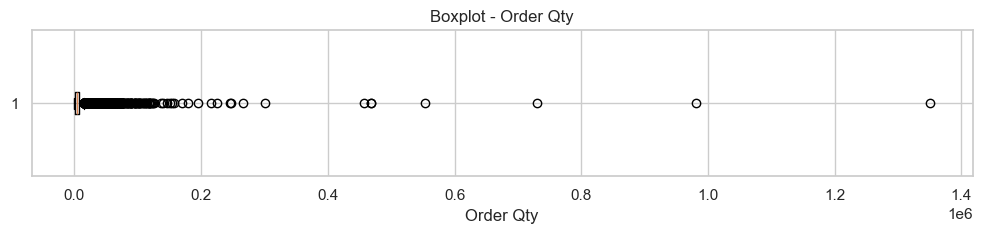


--- Cut Qty ---
Q1: 1598.62
Q3: 7053.38
IQR: 5454.75
Lower Bound: -6583.5
Upper Bound: 15235.5
Outliers: 1372 (8.99%)


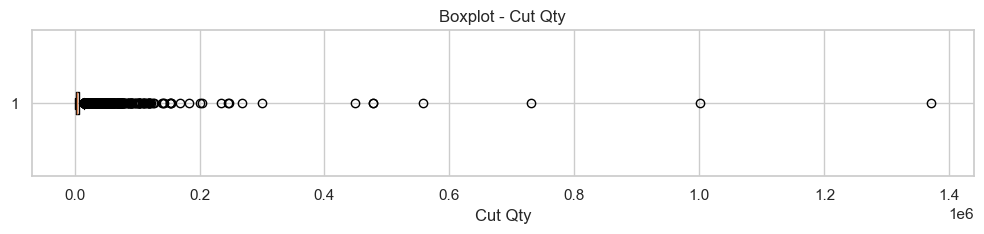


--- Ship Qty ---
Q1: 1531.5
Q3: 6853.88
IQR: 5322.38
Lower Bound: -6452.06
Upper Bound: 14837.44
Outliers: 1393 (9.12%)


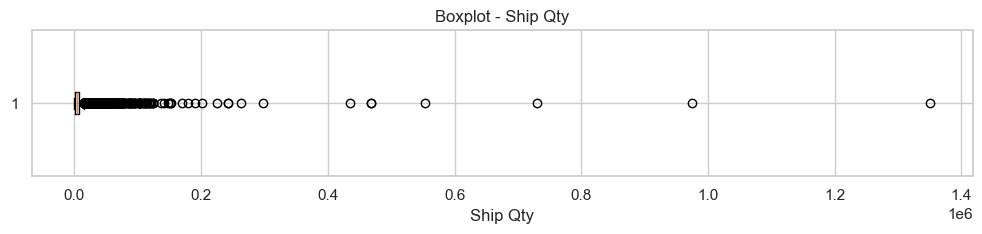


--- Cut/Ship ---
Q1: 0.95
Q3: 1.0
IQR: 0.05
Lower Bound: 0.88
Upper Bound: 1.07
Outliers: 1425 (9.33%)


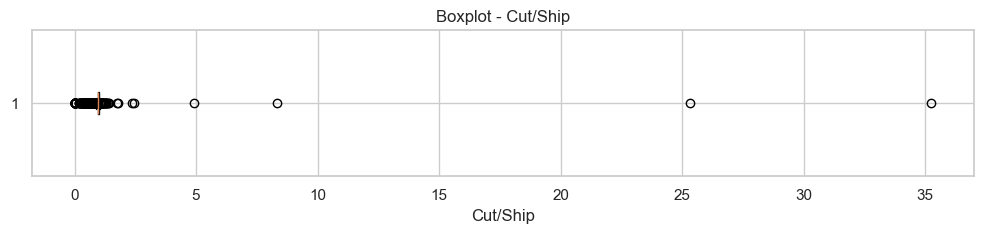


--- Order/Ship ---
Q1: 0.97
Q3: 1.0
IQR: 0.03
Lower Bound: 0.93
Upper Bound: 1.04
Outliers: 2333 (15.28%)


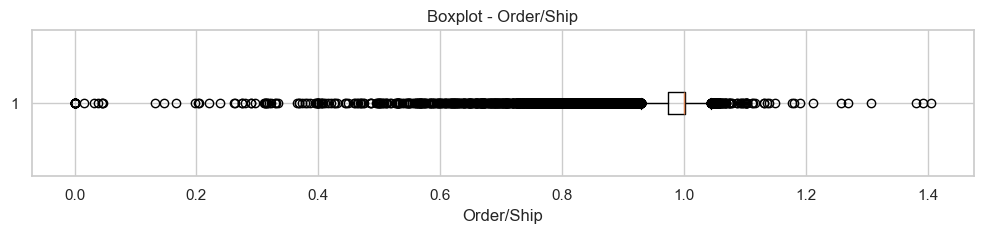


--- Order/Cut ---
Q1: 1.0
Q3: 1.03
IQR: 0.03
Lower Bound: 0.95
Upper Bound: 1.08
Outliers: 1051 (6.88%)


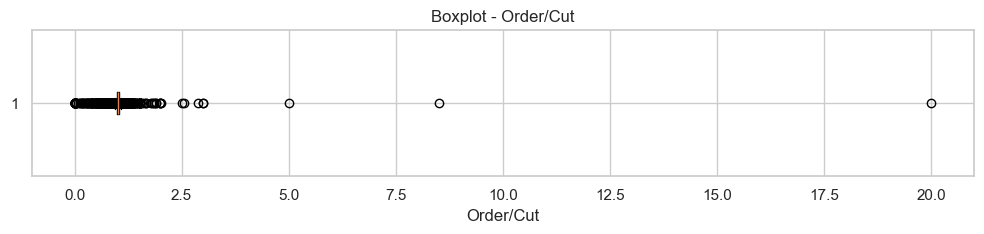


--- Cut ship Difference ---
Q1: 7.5
Q3: 159.0
IQR: 151.5
Lower Bound: -219.75
Upper Bound: 386.25
Outliers: 1762 (11.54%)


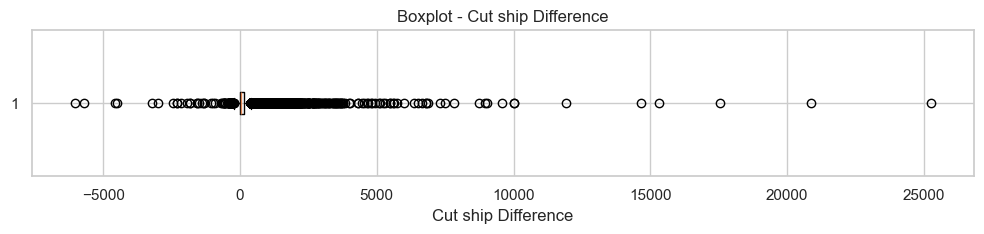

===== DISTRIBUTION ANALYSIS (OUTLIER-ADJUSTED) =====


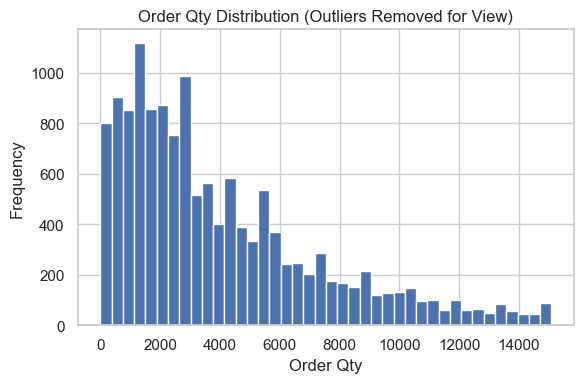

Order Qty Skewness (filtered): 1.195
Order Qty Original Skewness: 34.209
--------------------------------------------------


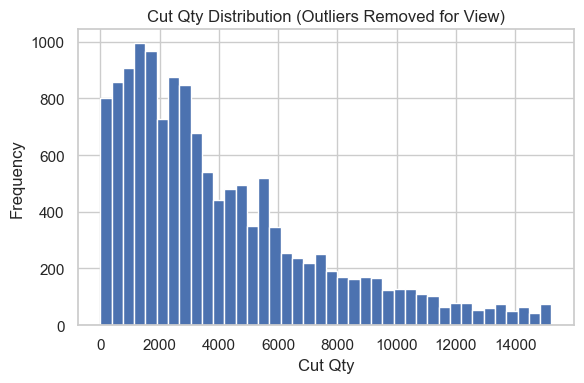

Cut Qty Skewness (filtered): 1.19
Cut Qty Original Skewness: 34.402
--------------------------------------------------


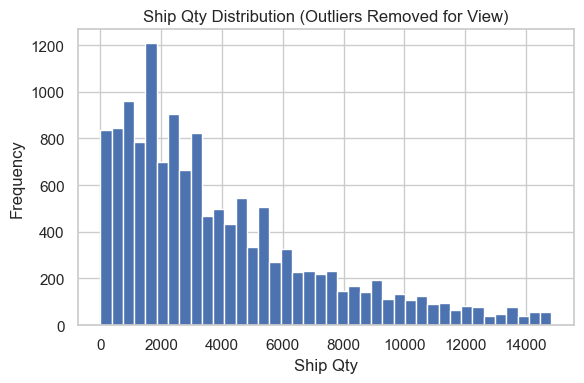

Ship Qty Skewness (filtered): 1.186
Ship Qty Original Skewness: 34.433
--------------------------------------------------


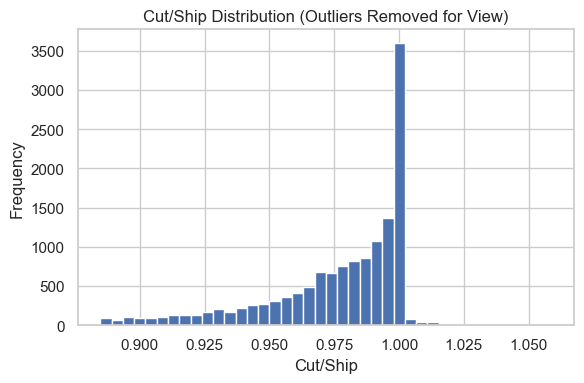

Cut/Ship Skewness (filtered): -1.28
Cut/Ship Original Skewness: 77.541
--------------------------------------------------


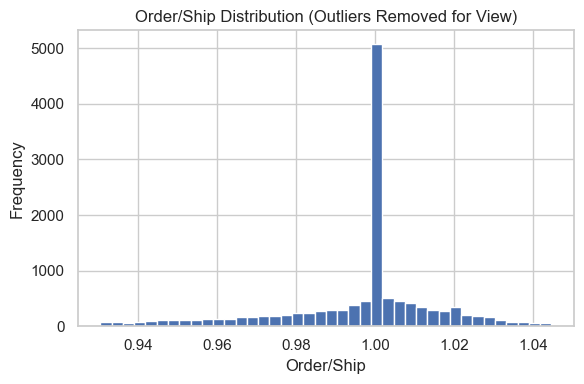

Order/Ship Skewness (filtered): -0.928
Order/Ship Original Skewness: -5.101
--------------------------------------------------


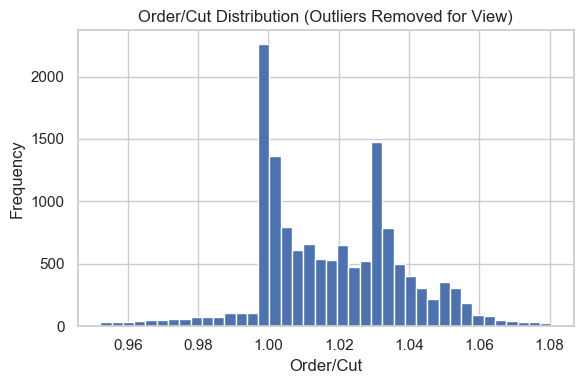

Order/Cut Skewness (filtered): 0.106
Order/Cut Original Skewness: 67.028
--------------------------------------------------


In [11]:
# =========================================================
# CELL 7: IQR OUTLIER DETECTION (KEY COLUMNS ONLY)
# ---------------------------------------------------------
# What this cell does:
# 1. Calculates IQR for selected key columns
# 2. Prints summary stats (no table)
# 3. Shows boxplots only (no histograms)
# 4. Uses cleaned "All" dataset
# =========================================================

# -----------------------------
# USE CLEANED "ALL" DATA
# -----------------------------

# 1. Load cleaned "All" sheet into working dataframe
df = cleaned_sheet_data["All"].copy()

# 2. Select key numeric columns for outlier analysis
plot_cols = [c for c in [
    "Order Qty", "Cut Qty", "Ship Qty",
    "Cut/Ship", "Order/Ship", "Order/Cut",
    "Cut ship Difference"
] if c in df.columns]

# 3. Print heading for IQR analysis
print("===== IQR OUTLIER ANALYSIS (KEY COLUMNS) =====")

# 4. Loop through each selected column
for col in plot_cols:
    s = df[col].dropna()

    # 5. Skip column if it has no usable values
    if len(s) == 0:
        continue

    # 6. Calculate quartiles and IQR
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    # 7. Calculate lower and upper bounds for outlier detection
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    # 8. Identify outlier values outside IQR bounds
    outliers = s[(s < lower) | (s > upper)]

    # 9. Print outlier summary statistics for each column
    print(f"\n--- {col} ---")
    print(f"Q1: {round(q1, 2)}")
    print(f"Q3: {round(q3, 2)}")
    print(f"IQR: {round(iqr, 2)}")
    print(f"Lower Bound: {round(lower, 2)}")
    print(f"Upper Bound: {round(upper, 2)}")
    print(f"Outliers: {len(outliers)} ({round((len(outliers)/len(s))*100, 2)}%)")

    # 10. Draw boxplot for visual outlier inspection
    plt.figure(figsize=(10, 2.5))
    plt.boxplot(s, vert=False)
    plt.title(f"Boxplot - {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


# =========================================================
# CELL 7B: DISTRIBUTION ANALYSIS (OUTLIER-ADJUSTED)
# ---------------------------------------------------------
# What this cell does:
# 1. Removes extreme values ONLY for visualization
# 2. Shows clearer distributions
# 3. Uses cleaned "All" dataset
# =========================================================

# 11. Select columns for distribution analysis
dist_cols = [
    "Order Qty", "Cut Qty", "Ship Qty",
    "Cut/Ship", "Order/Ship", "Order/Cut"
]

# 12. Print heading for adjusted distribution analysis
print("===== DISTRIBUTION ANALYSIS (OUTLIER-ADJUSTED) =====")

# 13. Loop through each selected column
for col in dist_cols:
    if col in df.columns:
        data = df[col].dropna()

        # 14. Skip column if it has no usable values
        if len(data) == 0:
            continue

        # 15. Calculate IQR bounds to remove extreme values for visualization only
        q1 = data.quantile(0.25)
        q3 = data.quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        # 16. Keep only values within IQR bounds for clearer plotting
        filtered = data[(data >= lower) & (data <= upper)]

        # 17. Plot histogram using filtered data
        plt.figure(figsize=(6, 4))
        plt.hist(filtered, bins=40)
        plt.title(f"{col} Distribution (Outliers Removed for View)")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()

        # 18. Print skewness before and after filtering
        print(f"{col} Skewness (filtered):", round(filtered.skew(), 3))
        print(f"{col} Original Skewness:", round(data.skew(), 3))
        print("-" * 50)

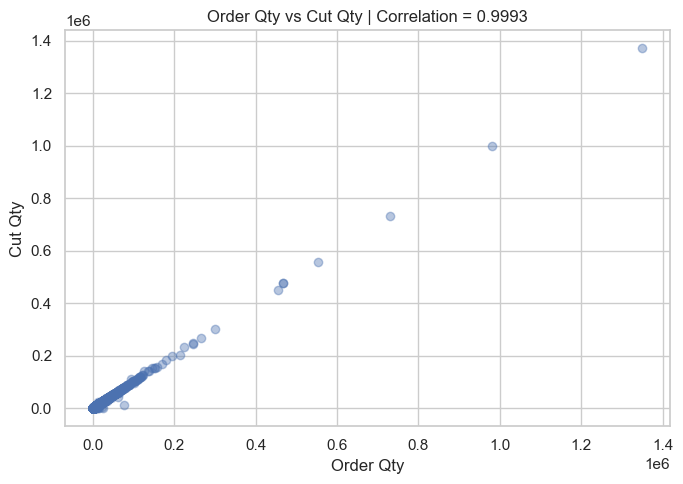

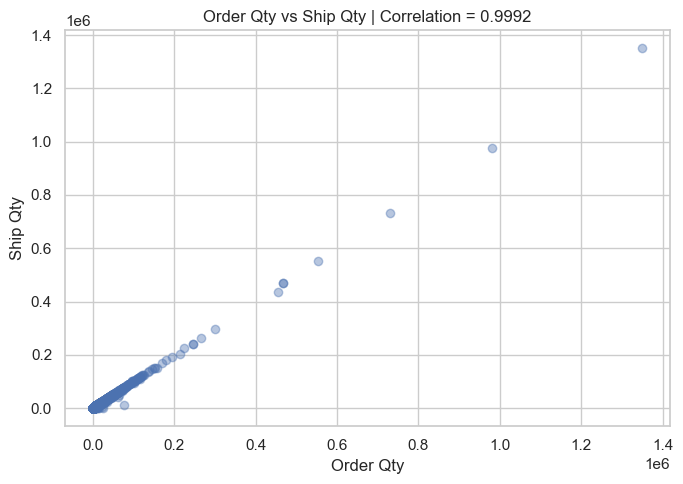

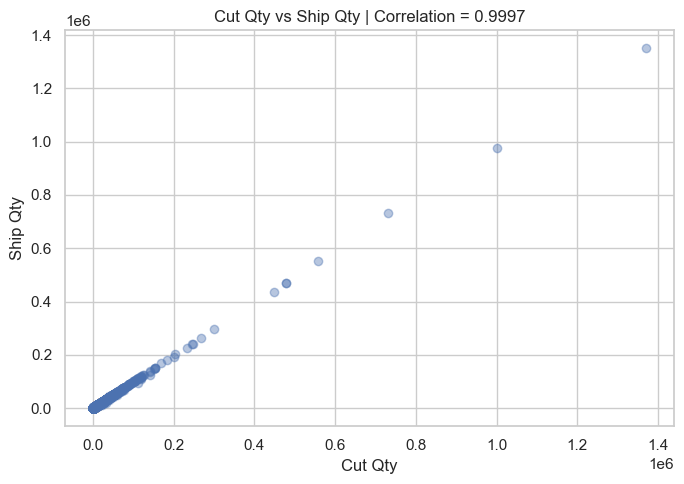

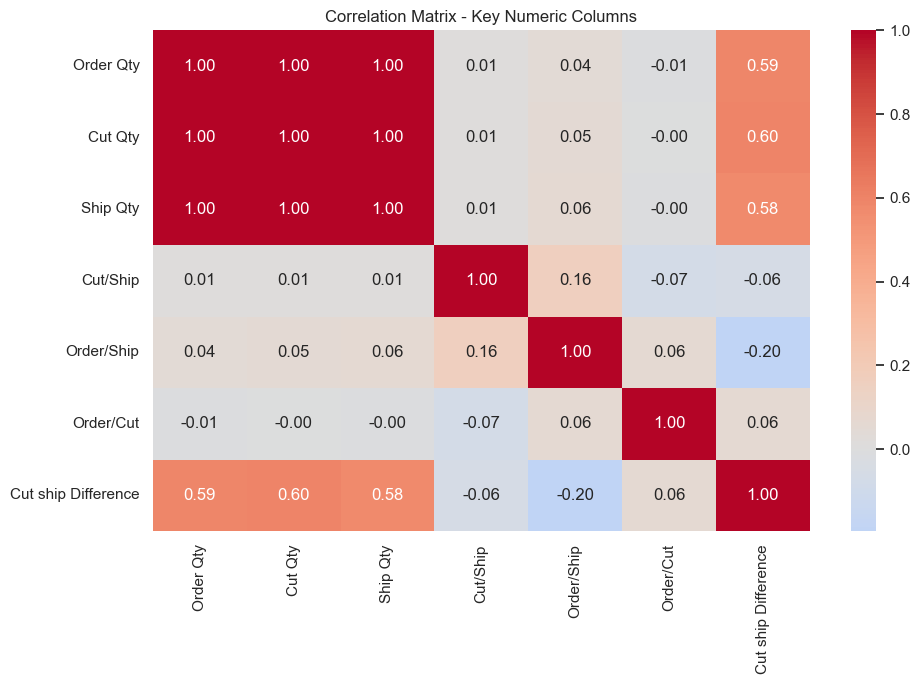


===== CORRELATIONS WITH Cut Qty =====
Top positive correlations:
- Ship Qty: 0.9997
- Order Qty: 0.9993
- Cut ship Difference: 0.5971
- Order/Ship: 0.0546
- Cut/Ship: 0.0129
Top negative correlations:
- Order/Cut: -0.0031
- Cut/Ship: 0.0129
- Order/Ship: 0.0546
- Cut ship Difference: 0.5971
- Order Qty: 0.9993

===== CORRELATIONS WITH Ship Qty =====
Top positive correlations:
- Cut Qty: 0.9997
- Order Qty: 0.9992
- Cut ship Difference: 0.5783
- Order/Ship: 0.0612
- Cut/Ship: 0.0148
Top negative correlations:
- Order/Cut: -0.0048
- Cut/Ship: 0.0148
- Order/Ship: 0.0612
- Cut ship Difference: 0.5783
- Order Qty: 0.9992


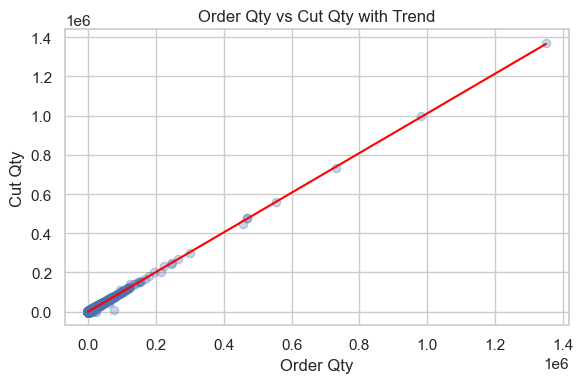

Trend slope (Order Qty -> Cut Qty): 1.0114
----------------------------------------


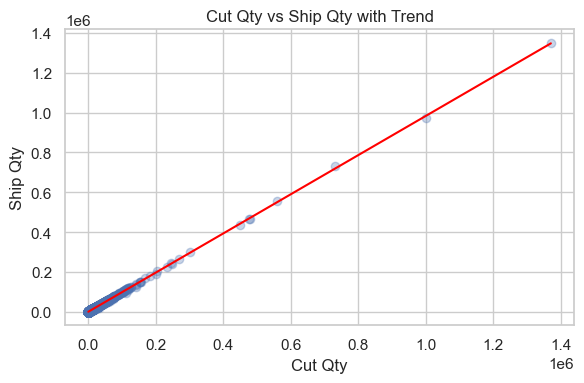

Trend slope (Cut Qty -> Ship Qty): 0.983
----------------------------------------


In [12]:
# =========================================================
# CELL 8: RELATIONSHIP ANALYSIS, CORRELATION, AND TARGET ANALYSIS
# ---------------------------------------------------------
# What this cell does:
# 1. Creates scatter plots for key quantity relationships
# 2. Builds correlation matrix for key numeric business columns
# 3. Shows strongest correlations with targets
# 4. Adds deeper relationship analysis with trend lines
# 5. Uses cleaned "All" dataset
# =========================================================

# -----------------------------
# USE CLEANED "ALL" DATA
# -----------------------------

# 1. Load cleaned "All" sheet into working dataframe
df = cleaned_sheet_data["All"].copy()

# -----------------------------
# Helper: clean numeric series for plotting / correlation
# -----------------------------

# 2. Create helper function to convert values to numeric and remove infinities
def finite_series(s):
    return pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)

# -----------------------------
# Scatter plots for key quantity relationships
# -----------------------------

# 3. Define key quantity pairs for relationship analysis
qty_pairs = [
    ("Order Qty", "Cut Qty"),
    ("Order Qty", "Ship Qty"),
    ("Cut Qty", "Ship Qty")
]

# 4. Loop through each pair and create scatter plots
for x_col, y_col in qty_pairs:
    if x_col in df.columns and y_col in df.columns:
        temp = df[[x_col, y_col]].copy()

        # 5. Clean both columns before plotting
        temp[x_col] = finite_series(temp[x_col])
        temp[y_col] = finite_series(temp[y_col])
        temp = temp.dropna()

        # 6. Skip if no valid data remains
        if len(temp) == 0:
            continue

        # 7. Calculate correlation between the two columns
        corr_val = temp[x_col].corr(temp[y_col])

        # 8. Create scatter plot with correlation in title
        plt.figure(figsize=(7, 5))
        plt.scatter(temp[x_col], temp[y_col], alpha=0.4)
        plt.title(f"{x_col} vs {y_col} | Correlation = {corr_val:.4f}")
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.tight_layout()
        plt.show()

# -----------------------------
# Correlation matrix for key numeric columns only
# -----------------------------

# 9. Select key numeric business columns for correlation analysis
corr_cols = [c for c in [
    "Order Qty", "Cut Qty", "Ship Qty",
    "Cut/Ship", "Order/Ship", "Order/Cut",
    "Cut ship Difference"
] if c in df.columns]

# 10. Build correlation matrix only if enough columns exist
if len(corr_cols) >= 2:
    corr_df = df[corr_cols].copy()

    # 11. Clean all selected columns before correlation calculation
    for col in corr_cols:
        corr_df[col] = finite_series(corr_df[col])

    # 12. Calculate correlation matrix
    corr_matrix = corr_df.corr()

    # 13. Plot correlation heatmap
    plt.figure(figsize=(10, 7))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
    plt.title("Correlation Matrix - Key Numeric Columns")
    plt.tight_layout()
    plt.show()

    # 14. Show strongest positive and negative correlations with target columns
    for target in ["Cut Qty", "Ship Qty"]:
        if target in corr_matrix.columns:
            target_corr = corr_matrix[target].drop(target).sort_values(ascending=False)

            print(f"\n===== CORRELATIONS WITH {target} =====")
            print("Top positive correlations:")
            for idx, val in target_corr.head(5).items():
                print(f"- {idx}: {val:.4f}")

            print("Top negative correlations:")
            for idx, val in target_corr.sort_values().head(5).items():
                print(f"- {idx}: {val:.4f}")
else:
    print("Not enough numeric columns available to build a correlation matrix.")

# =========================================================
# CELL 8B: RELATIONSHIP INSIGHTS (DEEPER)
# ---------------------------------------------------------
# What this cell does:
# 1. Adds trend understanding to key relationships
# 2. Uses cleaned "All" dataset
# =========================================================

# 15. Define key column pairs for deeper trend analysis
pairs = [
    ("Order Qty", "Cut Qty"),
    ("Cut Qty", "Ship Qty")
]

# 16. Loop through each pair and add trend line
for x_col, y_col in pairs:
    if x_col in df.columns and y_col in df.columns:
        temp = df[[x_col, y_col]].copy()

        # 17. Clean both columns before analysis
        temp[x_col] = finite_series(temp[x_col])
        temp[y_col] = finite_series(temp[y_col])
        temp = temp.dropna()

        # 18. Skip if there are not enough valid values
        if len(temp) < 2:
            print(f"Not enough valid data for {x_col} vs {y_col}")
            print("-" * 40)
            continue

        # 19. Plot scatter plot for deeper relationship view
        plt.figure(figsize=(6, 4))
        plt.scatter(temp[x_col], temp[y_col], alpha=0.3)

        # 20. Fit and plot linear trend line
        z = np.polyfit(temp[x_col], temp[y_col], 1)
        p = np.poly1d(z)
        x_sorted = np.sort(temp[x_col].values)
        plt.plot(x_sorted, p(x_sorted), color="red")

        plt.title(f"{x_col} vs {y_col} with Trend")
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.tight_layout()
        plt.show()

        # 21. Print slope of the fitted trend line
        print(f"Trend slope ({x_col} -> {y_col}):", round(z[0], 4))
        print("-" * 40)

In [13]:
# =========================================================
# CELL 9: ANOVA RESULTS + EXPORT UPDATED EDA OUTPUT
# ---------------------------------------------------------
# What this cell does:
# 1. Rebuilds summary outputs from updated Cells 1-8
# 2. Runs ANOVA for categorical features
# 3. Exports updated EDA outputs to Excel
# 4. Uses cleaned "All" dataset
# =========================================================

# 1. Import required libraries for data handling, ANOVA, and Excel formatting
import pandas as pd
import numpy as np
import os
from scipy.stats import f_oneway
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Border, Side, Alignment
from openpyxl.worksheet.table import Table, TableStyleInfo
from openpyxl.utils import get_column_letter

# -----------------------------
# USE CLEANED "ALL" DATA
# -----------------------------

# 2. Load cleaned "All" sheet into working dataframe
df = cleaned_sheet_data["All"].copy()

# =========================================================
# REBUILD SUMMARY TABLES NEEDED FOR EXPORT
# =========================================================

# -----------------------------
# 1. Duplicate summary
# -----------------------------

# 3. Count occurrences of each Code and identify duplicates
duplicate_code_counts = df["Code"].value_counts(dropna=True)
duplicate_codes = duplicate_code_counts[duplicate_code_counts > 1]

# 4. Create duplicate summary statistics table
duplicate_summary_stats = pd.DataFrame({
    "Metric": [
        "Total rows",
        "Unique Codes",
        "Number of duplicate Code values",
        "Rows involved in duplicate Codes"
    ],
    "Value": [
        len(df),
        df["Code"].nunique(dropna=True),
        len(duplicate_codes),
        int(duplicate_codes.sum()) if len(duplicate_codes) > 0 else 0
    ]
})

# 5. Create duplicate detail table
duplicate_detail = duplicate_codes.reset_index()
if not duplicate_detail.empty:
    duplicate_detail.columns = ["Code", "Record Count"]
else:
    duplicate_detail = pd.DataFrame(columns=["Code", "Record Count"])

# -----------------------------
# 2. Negative value summary
# -----------------------------

# 6. Define columns where negative values are allowed
negative_allowed_cols = [
    "Cut ship Difference",
    "FOB-Impact due to Cut to Ship Difference",
    "Metric A",
    "Metric B",
    "Metric C",
    "Metric D",
    "Metric E",
    "Metric F",
    "Metric G",
    "Metric H",
    "Metric I",
    "Metric J",
    "Metric K",
    "Metric L",
    "Metric M",
    "Metric N",
    "Metric O",
    "Metric P",
    "Metric Q",
    "Metric R",
    "Metric S"
]
negative_allowed_cols = [c for c in negative_allowed_cols if c in df.columns]

# 7. Select numeric columns and exclude allowed negative columns
numeric_cols_export = df.select_dtypes(include=[np.number]).columns.tolist()
negative_check_cols = [c for c in numeric_cols_export if c not in negative_allowed_cols]

# 8. Build negative value detail summary
negative_summary = []
for col in negative_check_cols:
    neg_count = int((df[col] < 0).sum(skipna=True))
    neg_pct = round((neg_count / len(df)) * 100, 4) if len(df) > 0 else 0
    if neg_count > 0:
        negative_summary.append({
            "Column": col,
            "Negative Count": neg_count,
            "Negative %": neg_pct
        })

# 9. Convert negative summary into dataframe
negative_summary_df = pd.DataFrame(negative_summary)
if negative_summary_df.empty:
    negative_summary_df = pd.DataFrame(columns=["Column", "Negative Count", "Negative %"])

# 10. Create negative value summary statistics table
negative_stats = pd.DataFrame({
    "Metric": [
        "Numeric columns checked",
        "Columns excluded from negative check",
        "Columns with negative values found"
    ],
    "Value": [
        len(negative_check_cols),
        len(negative_allowed_cols),
        len(negative_summary)
    ]
})

# -----------------------------
# 3. IQR summary for key columns only
# -----------------------------

# 11. Select key columns for IQR summary
iqr_cols = [c for c in [
    "Order Qty", "Cut Qty", "Ship Qty",
    "Cut/Ship", "Order/Ship", "Order/Cut",
    "Cut ship Difference"
] if c in df.columns]

# 12. Calculate IQR-based outlier summary for key columns
iqr_rows = []
for col in iqr_cols:
    s = df[col].dropna()
    if len(s) == 0:
        continue

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = s[(s < lower) | (s > upper)]

    iqr_rows.append({
        "Column": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": len(outliers),
        "Outlier %": round((len(outliers) / len(s)) * 100, 2)
    })

# 13. Convert IQR results into dataframe
iqr_key_summary = pd.DataFrame(iqr_rows)

# -----------------------------
# 4. Target correlations only
# -----------------------------

# 14. Select key numeric columns for target correlation export
corr_cols = [c for c in [
    "Order Qty", "Cut Qty", "Ship Qty",
    "Cut/Ship", "Order/Ship", "Order/Cut",
    "Cut ship Difference"
] if c in df.columns]

# 15. Create list to store target correlation rows
corr_target_summary_rows = []

# 16. Build target correlation summary
if len(corr_cols) >= 2:
    corr_df_export = df[corr_cols].copy()
    for col in corr_cols:
        corr_df_export[col] = pd.to_numeric(corr_df_export[col], errors="coerce").replace([np.inf, -np.inf], np.nan)

    corr_matrix_export = corr_df_export.corr()

    for target in ["Cut Qty", "Ship Qty"]:
        if target in corr_matrix_export.columns:
            temp_corr = corr_matrix_export[target].drop(target).sort_values(ascending=False)
            for feature, corr_val in temp_corr.items():
                corr_target_summary_rows.append({
                    "Target": target,
                    "Feature": feature,
                    "Correlation": corr_val
                })

# 17. Convert target correlation results into dataframe
corr_target_summary = pd.DataFrame(corr_target_summary_rows)

# =========================================================
# ANOVA FOR CATEGORICAL FEATURES
# =========================================================

# 18. Select categorical ML feature columns for ANOVA
categorical_anova_cols = [
    c for c in use_cols
    if c in df.columns and not pd.api.types.is_numeric_dtype(df[c])
]

# 19. Create list to store ANOVA results
anova_rows = []

# 20. Run ANOVA for each categorical feature against Cut Qty and Ship Qty
for col in categorical_anova_cols:
    try:
        temp_cut = df[[col, "Cut Qty"]].dropna()
        cut_p = np.nan
        cut_groups_used = 0

        if temp_cut[col].nunique() > 1:
            groups_cut = [grp["Cut Qty"].values for _, grp in temp_cut.groupby(col) if len(grp) > 1]
            if len(groups_cut) > 1:
                cut_p = f_oneway(*groups_cut).pvalue
                cut_groups_used = len(groups_cut)

        temp_ship = df[[col, "Ship Qty"]].dropna()
        ship_p = np.nan
        ship_groups_used = 0

        if temp_ship[col].nunique() > 1:
            groups_ship = [grp["Ship Qty"].values for _, grp in temp_ship.groupby(col) if len(grp) > 1]
            if len(groups_ship) > 1:
                ship_p = f_oneway(*groups_ship).pvalue
                ship_groups_used = len(groups_ship)

        anova_rows.append({
            "Categorical Feature": col,
            "Groups Used for Cut Qty": cut_groups_used,
            "Cut Qty p-value": cut_p,
            "Cut Qty Significant?": "Yes" if pd.notna(cut_p) and cut_p < 0.05 else "No",
            "Groups Used for Ship Qty": ship_groups_used,
            "Ship Qty p-value": ship_p,
            "Ship Qty Significant?": "Yes" if pd.notna(ship_p) and ship_p < 0.05 else "No"
        })

    except Exception:
        pass

# 21. Convert ANOVA results into dataframe and sort by p-values
anova_results = pd.DataFrame(anova_rows)

if not anova_results.empty:
    anova_results = anova_results.sort_values(
        ["Cut Qty p-value", "Ship Qty p-value"],
        ascending=[True, True],
        na_position="last"
    )

# 22. Display ANOVA results
print("===== ANOVA RESULTS FOR CATEGORICAL FEATURES =====")
display(anova_results)

# =========================================================
# EXPORT TO EXCEL
# =========================================================

# 23. Define output file path for EDA export
output_path = r"D:\Savidhu_OneDrive\OneDrive - Hirdaramani Group\Projects\Cut to Ship Prediction Model\Final Report\Cut to Ship Modified EDA.xlsx"

# 24. Export main EDA summary tables to separate Excel sheets
with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    overview.to_excel(writer, sheet_name="Overview", index=False)
    feature_screening.drop(columns=["Rec_Order"], errors="ignore").to_excel(writer, sheet_name="Feature_Screening", index=False)
    numeric_summary.to_excel(writer, sheet_name="Numeric_Summary", index=False)
    categorical_summary.to_excel(writer, sheet_name="Categorical_Summary", index=False)
    iqr_key_summary.to_excel(writer, sheet_name="IQR_Key_Columns", index=False)

    if not corr_target_summary.empty:
        corr_target_summary.to_excel(writer, sheet_name="Target_Correlations", index=False)

    if not anova_results.empty:
        anova_results.to_excel(writer, sheet_name="ANOVA_Categorical", index=False)

# =========================================================
# ADD COMBINED SHEET FOR DUPLICATES + NEGATIVES
# =========================================================

# 25. Open exported workbook for additional formatting and sheet creation
wb = load_workbook(output_path)

# 26. Remove existing Checks_Summary sheet if it already exists
if "Checks_Summary" in wb.sheetnames:
    del wb["Checks_Summary"]

# 27. Create combined checks summary sheet
ws = wb.create_sheet("Checks_Summary")

# 28. Set starting row position
current_row = 1

# 29. Create helper function to write a titled section into the checks sheet
def write_section(ws, title, df_section, start_row):
    ws.cell(row=start_row, column=1, value=title)
    title_cell = ws.cell(row=start_row, column=1)
    title_cell.font = Font(bold=True)

    if df_section is None or df_section.empty:
        ws.cell(row=start_row + 1, column=1, value="No data")
        return start_row + 3

    for j, col_name in enumerate(df_section.columns, start=1):
        ws.cell(row=start_row + 1, column=j, value=col_name)

    for i, row_vals in enumerate(df_section.itertuples(index=False), start=start_row + 2):
        for j, val in enumerate(row_vals, start=1):
            ws.cell(row=i, column=j, value=val)

    end_row = start_row + 1 + len(df_section)
    return end_row + 2

# 30. Write duplicate and negative check sections into the combined sheet
current_row = write_section(ws, "Duplicate Summary", duplicate_summary_stats, current_row)
current_row = write_section(ws, "Duplicate Detail", duplicate_detail, current_row)
current_row = write_section(ws, "Negative Summary", negative_stats, current_row)
current_row = write_section(ws, "Negative Detail", negative_summary_df, current_row)

# =========================================================
# FORMAT EXCEL
# =========================================================

# 31. Define reusable Excel styles
header_fill = PatternFill(fill_type="solid", fgColor="1F4E78")
header_font = Font(color="FFFFFF", bold=True)
thin_border = Border(
    left=Side(style="thin", color="D9D9D9"),
    right=Side(style="thin", color="D9D9D9"),
    top=Side(style="thin", color="D9D9D9"),
    bottom=Side(style="thin", color="D9D9D9")
)

# 32. Loop through all worksheets and apply formatting
for ws in wb.worksheets:
    max_row = ws.max_row
    max_col = ws.max_column

    # 33. Apply borders and alignment to all cells
    for row in ws.iter_rows():
        for cell in row:
            cell.border = thin_border
            cell.alignment = Alignment(horizontal="center", vertical="center")

    # 34. Format normal sheet headers
    if ws.title != "Checks_Summary":
        for cell in ws[1]:
            cell.fill = header_fill
            cell.font = header_font
            cell.alignment = Alignment(horizontal="center", vertical="center")
            cell.border = thin_border

    # 35. Format special section headers inside Checks_Summary sheet
    if ws.title == "Checks_Summary":
        for row in range(1, max_row + 1):
            first_val = ws.cell(row=row, column=1).value

            if isinstance(first_val, str) and first_val in ["Duplicate Summary", "Duplicate Detail", "Negative Summary", "Negative Detail"]:
                ws.cell(row=row, column=1).fill = header_fill
                ws.cell(row=row, column=1).font = header_font
                ws.cell(row=row, column=1).alignment = Alignment(horizontal="center", vertical="center")
                for c in range(2, max_col + 1):
                    ws.cell(row=row, column=c).fill = header_fill
                    ws.cell(row=row, column=c).border = thin_border

            if isinstance(first_val, str) and first_val in ["Metric", "Value", "Code", "Record Count", "Column", "Negative Count", "Negative %"]:
                for c in range(1, max_col + 1):
                    ws.cell(row=row, column=c).fill = header_fill
                    ws.cell(row=row, column=c).font = header_font
                    ws.cell(row=row, column=c).alignment = Alignment(horizontal="center", vertical="center")
                    ws.cell(row=row, column=c).border = thin_border

    # 36. Auto-adjust column widths
    for col_cells in ws.columns:
        max_length = 0
        col_letter = get_column_letter(col_cells[0].column)

        for cell in col_cells:
            try:
                cell_value = "" if cell.value is None else str(cell.value)
                max_length = max(max_length, len(cell_value))
            except Exception:
                pass

        ws.column_dimensions[col_letter].width = min(max_length + 2, 40)

    # 37. Apply number formatting
    for row in ws.iter_rows(min_row=2):
        for cell in row:
            if isinstance(cell.value, (int, float)) and cell.value is not None:
                if ws.title != "Checks_Summary":
                    true_header = str(ws.cell(row=1, column=cell.column).value).lower()
                    if "p-value" in true_header:
                        cell.number_format = "0.000000"
                    elif "%" in true_header:
                        cell.number_format = "0.00"
                    else:
                        cell.number_format = "#,##0.00"
                else:
                    cell.number_format = "#,##0.00"

    # 38. Add Excel table formatting to regular sheets
    if ws.title != "Checks_Summary" and ws.max_row >= 2 and ws.max_column >= 1:
        ref = f"A1:{get_column_letter(ws.max_column)}{ws.max_row}"
        table_name = f"Tbl_{ws.title.replace(' ', '_').replace('-', '_')[:20]}"
        table = Table(displayName=table_name, ref=ref)
        style = TableStyleInfo(
            name="TableStyleMedium9",
            showFirstColumn=False,
            showLastColumn=False,
            showRowStripes=True,
            showColumnStripes=False
        )
        table.tableStyleInfo = style

        try:
            ws.add_table(table)
        except Exception:
            pass

# 39. Save final formatted workbook
wb.save(output_path)

# 40. Print final export path
print("\nEDA output saved to:")
print(output_path)

===== ANOVA RESULTS FOR CATEGORICAL FEATURES =====


,Categorical Feature,Groups Used for Cut Qty,Cut Qty p-value,Cut Qty Significant?,Groups Used for Ship Qty,Ship Qty p-value,Ship Qty Significant?
0,Customers,53,0.000000e+00,Yes,53,0.000000e+00,Yes
1,Calling Name,53,0.000000e+00,Yes,53,0.000000e+00,Yes
3,Season,80,5.857432e-134,Yes,80,5.465178e-131,Yes
2,Div,42,1.224726e-56,Yes,42,1.537880e-58,Yes
4,Garment item type,86,2.745255e-48,Yes,86,3.105186e-49,Yes
5,Unit,13,5.695244e-36,Yes,13,9.867785e-38,Yes
6,Operation,3,7.729533e-17,Yes,3,1.896006e-18,Yes
8,Type,3,2.503519e-14,Yes,3,3.385550e-16,Yes
10,Operation 2,2,2.308353e-11,Yes,2,2.531188e-12,Yes
11,Set garment,2,5.311531e-03,Yes,2,1.333002e-02,Yes



EDA output saved to:
D:\Savidhu_OneDrive\OneDrive - Hirdaramani Group\Projects\Cut to Ship Prediction Model\Final Report\Cut to Ship Modified EDA.xlsx
